In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
from scipy.ndimage import median_filter
from utils.colors import COLORS
from scipy.ndimage import median_filter, binary_erosion, binary_dilation, binary_fill_holes
from scipy.spatial import distance
import numpy as np
import os
from tqdm import tqdm

In [2]:
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

#### 2D DDPM

In [3]:
scores = {
    "2d_ddpm_1x": {
        "large": {
            "adc": {"mean_dice": 0.58, "lower_ci": 0.53, "upper_ci": 0.64},
            "flair": {"mean_dice": 0.52, "lower_ci": 0.47, "upper_ci": 0.56},
            "combined": {"mean_dice": 0.70, "lower_ci": 0.65, "upper_ci": 0.74}
        },
        "medium": {
            "adc": {"mean_dice": 0.52, "lower_ci": 0.47, "upper_ci": 0.57},
            "flair": {"mean_dice": 0.43, "lower_ci": 0.38, "upper_ci": 0.48},
            "combined": {"mean_dice": 0.53, "lower_ci": 0.49, "upper_ci": 0.58}
        },
        "small": {
            "adc": {"mean_dice": 0.07, "lower_ci": 0.04, "upper_ci": 0.10},
            "flair": {"mean_dice": 0.11, "lower_ci": 0.09, "upper_ci": 0.15},
            "combined": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00}
        }
    },
    "2d_ddpm_10x": {
        "large": {
            "adc": {"mean_dice": 0.60, "lower_ci": 0.55, "upper_ci": 0.66},
            "flair": {"mean_dice": 0.51, "lower_ci": 0.46, "upper_ci": 0.56},
            "combined": {"mean_dice": 0.68, "lower_ci": 0.63, "upper_ci": 0.72}
            },
        "medium": {
            "adc": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00},
            "flair": {"mean_dice": 0.39, "lower_ci": 0.35, "upper_ci": 0.43},
            "combined": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00}
        },
        "small": {
            "adc": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00},
            "flair": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00},
            "combined": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00}
        }
    },
    "3d_ddpm_1x": {
        "large": {
            "adc": {"mean_dice": 0.57, "lower_ci": 0.52, "upper_ci": 0.63},
            "flair": {"mean_dice": 0.43, "lower_ci": 0.37, "upper_ci": 0.50},
            "combined": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00}
            },
        "medium": {
            "adc": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00},
            "flair": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00},
            "combined": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00}
        },
        "small": {
            "adc": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00},
            "flair": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00},
            "combined": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00}
        }
    },
    "3d_ddpm_10x": {
        "large": {
            "adc": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00},
            "flair": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00},
            "combined": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00}
            },
        "medium": {
            "adc": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00},
            "flair": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00},
            "combined": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00}
        },
        "small": {
            "adc": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00},
            "flair": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00},
            "combined": {"mean_dice": 0.00, "lower_ci": 0.00, "upper_ci": 0.00}
        }
    }
}

In [4]:
model = "2d_ddpm_1x"
group = "large"

In [ ]:
make three graphs just like this for each group: large, medium and small. On the same row

In [ ]:
mean_dice = [scores[model][group]["adc"]["mean_dice"], scores[model][group]["flair"]["mean_dice"], scores[model][group]["combined"]["mean_dice"]]

lower_bounds = [scores[model][group]["adc"]["lower_ci"], scores[model][group]["flair"]["lower_ci"], scores[model][group]["combined"]["lower_ci"]]

upper_bounds = [scores[model][group]["adc"]["upper_ci"], scores[model][group]["flair"]["upper_ci"], scores[model][group]["combined"]["upper_ci"]]

titles = ["ADC", "FLAIR", "Combined"]

# Note: "#9faffff" is not a valid hex length, so it is corrected to "#9fafffff"
bar_colors = [COLORS.MEDIUM_RED, COLORS.MEDIUM_BLUE, COLORS.MEDIUM_GREEN]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(5, 4), sharey=True)

for ax, title, score, low, high, color in zip(
    axes, titles, mean_dice, lower_bounds, upper_bounds, bar_colors
):
    sns.barplot(x=[title], y=[score], color=color, ax=ax)
    ax.errorbar(
        x=[0],
        y=[score],
        yerr=[[score - low], [high - score]],
        fmt="none",
        ecolor="black",
        capsize=6,
        linewidth=1.5
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Dice score")
    ax.set_ylim(0, 1)

plt.suptitle(f"{model.replace('_', ' ').upper()} inference {group} group [95% Confidence Intervals]", fontsize=16)

plt.tight_layout()
plt.show()

/tmp/ipykernel_32334/3930608411.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=titles, y=mean_dice, palette=bar_colors, ax=ax)
/tmp/ipykernel_32334/3930608411.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=titles, y=mean_dice, palette=bar_colors, ax=ax)
/tmp/ipykernel_32334/3930608411.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=titles, y=mean_dice, palette=bar_colors, ax=ax)


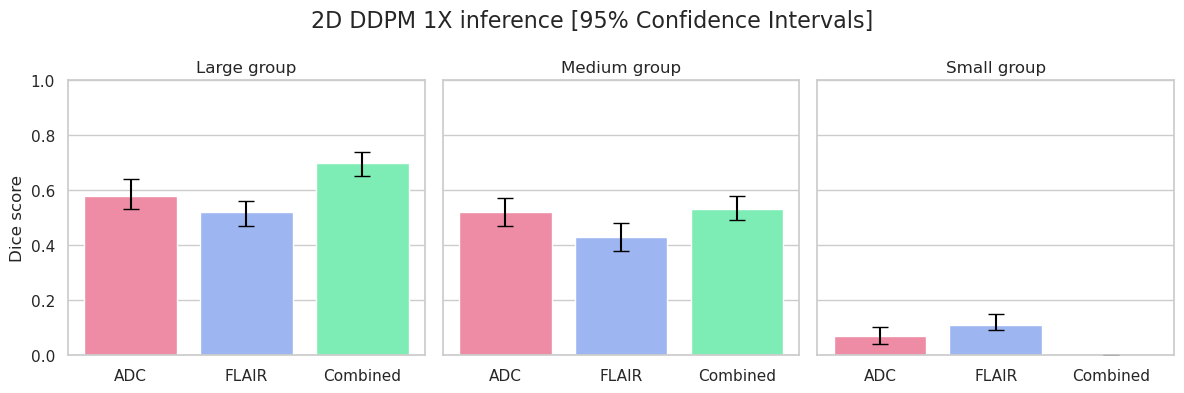

In [9]:
groups = ["large", "medium", "small"]
titles = ["ADC", "FLAIR", "Combined"]
bar_colors = [COLORS.MEDIUM_RED, COLORS.MEDIUM_BLUE, COLORS.MEDIUM_GREEN]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for ax, group in zip(axes, groups):
    mean_dice = [
        scores[model][group]["adc"]["mean_dice"],
        scores[model][group]["flair"]["mean_dice"],
        scores[model][group]["combined"]["mean_dice"]
    ]
    
    lower_bounds = [
        scores[model][group]["adc"]["lower_ci"],
        scores[model][group]["flair"]["lower_ci"],
        scores[model][group]["combined"]["lower_ci"]
    ]
    
    upper_bounds = [
        scores[model][group]["adc"]["upper_ci"],
        scores[model][group]["flair"]["upper_ci"],
        scores[model][group]["combined"]["upper_ci"]
    ]

    sns.barplot(x=titles, y=mean_dice, palette=bar_colors, ax=ax)
    
    for i, (score, low, high) in enumerate(zip(mean_dice, lower_bounds, upper_bounds)):
        ax.errorbar(
            x=[i],
            y=[score],
            yerr=[[score - low], [high - score]],
            fmt="none",
            ecolor="black",
            capsize=6,
            linewidth=1.5
        )
        
    ax.set_title(f"{group.capitalize()} group")
    ax.set_xlabel("")
    ax.set_ylabel("Dice score" if group == "large" else "")
    ax.set_ylim(0, 1)

plt.suptitle(f"{model.replace('_', ' ').upper()} inference [95% Confidence Intervals]", fontsize=16)

plt.tight_layout()
plt.show()

### Example patients

In [72]:
medium_2d_ddpm_patients_to_try = [filename.split('_')[0] for filename in os.listdir(f"{ROOT_DIR}datasets/anomaly_maps/exp_2_2_fixed/for_combine_experiment/medium/")]

In [73]:
print("Medium 2D DDPM patients to try:")
for patient in medium_2d_ddpm_patients_to_try:
    print(patient)

Medium 2D DDPM patients to try:
sub-416
sub-33
sub-296
sub-384
sub-449
sub-478
sub-375
sub-204
sub-663
sub-622
sub-595
sub-277
sub-1673
sub-947
sub-1684
sub-546
sub-998
sub-377
sub-297
sub-703
sub-657
sub-870
sub-908
sub-1674
sub-717
sub-888
sub-944
sub-554
sub-426
sub-305
sub-473
sub-203
sub-860
sub-589
sub-869
sub-510
sub-67
sub-522
sub-965
sub-408
sub-295
sub-794
sub-557
sub-165
sub-795
sub-467
sub-415
sub-273
sub-1678
sub-322
sub-654
sub-289
sub-50
sub-403
sub-1722
sub-587
sub-420
sub-274
sub-518
sub-969
sub-485
sub-1682
sub-918
sub-996
sub-674
sub-580
sub-839
sub-487
sub-332
sub-507
sub-355
sub-206
sub-972
sub-462
sub-542
sub-681
sub-943
sub-853
sub-807
sub-49
sub-848
sub-821
sub-1672
sub-927
sub-320
sub-991
sub-616
sub-552
sub-27
sub-976
sub-880
sub-544
sub-9
sub-515
sub-435
sub-62
sub-931
sub-924
sub-801
sub-35
sub-759
sub-330
sub-1690
sub-1652
sub-596
sub-397
sub-36
sub-490
sub-219
sub-364
sub-245
sub-551


In [74]:
combine_median_filter_size = 0
combine_threshold = 0.03
combine_erosion_dilation_steps = 4
combine_fill_holes = True

In [75]:
# simple DICE function
def dice_score_func(pred, gt):
    intersection = (pred & gt).sum()
    pred_sum = pred.sum()
    gt_sum = gt.sum()
    
    if pred_sum + gt_sum == 0:
        return 1.0
    
    return 2 * intersection / (pred_sum + gt_sum)

In [ ]:
for current_patient in tqdm(medium_2d_ddpm_patients_to_try):
    original_adc = nib.load(f"{ROOT_DIR}datasets/final_soop_dataset_small/adc_registered/{current_patient}.nii.gz").get_fdata()
    raw_adc_ano_map  = nib.load(f"{ROOT_DIR}datasets/anomaly_maps/exp_2_2_fixed/for_combine_experiment/medium/{current_patient}_t_130.nii.gz").get_fdata()


    original_flair = nib.load(f"{ROOT_DIR}datasets/final_soop_dataset_small/flair_registered/{current_patient}.nii.gz").get_fdata()
    raw_flair_ano_map  = nib.load(f"{ROOT_DIR}datasets/anomaly_maps/exp_3_2_fixed/for_combine_experiment/medium/{current_patient}_t_130.nii.gz").get_fdata()

    ground_truth_mask = nib.load(f"{ROOT_DIR}datasets/final_soop_dataset_small/masks_combined_registered/{current_patient}.nii.gz").get_fdata() > 0
    
    # Apply the median filter using the previously defined size
    #processed_adc_ano_map = median_filter(raw_adc_ano_map, size=combine_median_filter_size)
    processed_adc_ano_map = raw_adc_ano_map
    #processed_flair_ano_map = median_filter(raw_flair_ano_map, size=combine_median_filter_size)
    processed_flair_ano_map = raw_flair_ano_map
    
    combined_ano_map = (processed_adc_ano_map + processed_flair_ano_map)/2

    combined_segmentation_raw = combined_ano_map > combine_threshold
    combined_segmentation_processed = combined_segmentation_raw.copy()
    for _ in range(combine_erosion_dilation_steps):
        combined_segmentation_processed = binary_erosion(combined_segmentation_processed)
    for _ in range(combine_erosion_dilation_steps):
        combined_segmentation_processed = binary_dilation(combined_segmentation_processed)

    combined_segmentation_processed = binary_fill_holes(combined_segmentation_processed) if combine_fill_holes else combined_segmentation_processed

    slice_idx = 64

    fig, axes = plt.subplots(2, 7, figsize=(23, 7))

    dice_score = dice_score_func(np.asarray(ground_truth_mask, dtype=np.int16), np.asarray(combined_segmentation_processed, dtype=np.int16))

    # ADC row
    axes[0, 0].imshow(original_adc[:, :, slice_idx], cmap='gray')
    axes[0, 0].set_title('Original ADC')
    axes[0, 1].imshow(raw_adc_ano_map[:, :, slice_idx], cmap='jet', vmin=0, vmax=0.2)
    axes[0, 1].set_title('Raw ADC Ano Map')
    axes[0, 2].imshow(processed_adc_ano_map[:, :, slice_idx], cmap='jet', vmin=0, vmax=0.2)
    axes[0, 2].set_title('Processed ADC Ano Map')
    #axes[0, 3].imshow(combined_ano_map[:, :, slice_idx], cmap='jet', vmin=0, vmax=0.2)
    #axes[0, 3].set_title('Combined Ano Map')
    #axes[0, 4].imshow(combined_segmentation_raw[:, :, slice_idx], cmap='gray')
    #axes[0, 4].set_title('Combined Raw Seg')
    #axes[0, 5].imshow(combined_segmentation_processed[:, :, slice_idx], cmap='gray')
    #axes[0, 5].set_title('Combined Processed Seg')
    #axes[0, 6].imshow(ground_truth_mask[:, :, slice_idx], cmap='gray')
    #axes[0, 6].set_title(f'Ground Truth Mask Dice: {dice_score:.2f}')

    # FLAIR row
    axes[1, 0].imshow(original_flair[:, :, slice_idx], cmap='gray')
    axes[1, 0].set_title('Original FLAIR')
    axes[1, 1].imshow(raw_flair_ano_map[:, :, slice_idx], cmap='jet', vmin=0, vmax=0.2)
    axes[1, 1].set_title('Raw FLAIR Ano Map')
    axes[1, 2].imshow(processed_flair_ano_map[:, :, slice_idx], cmap='jet', vmin=0, vmax=0.2)
    axes[1, 2].set_title('Processed FLAIR Ano Map')
    axes[1, 3].imshow(combined_ano_map[:, :, slice_idx], cmap='jet', vmin=0, vmax=0.2)
    axes[1, 3].set_title('Combined Ano Map')
    axes[1, 4].imshow(combined_segmentation_raw[:, :, slice_idx], cmap='gray')
    axes[1, 4].set_title('Combined Raw Seg')
    axes[1, 5].imshow(combined_segmentation_processed[:, :, slice_idx], cmap='gray')
    axes[1, 5].set_title('Combined Processed Seg')
    axes[1, 6].imshow(ground_truth_mask[:, :, slice_idx], cmap='gray')
    axes[1, 6].set_title(f'Ground Truth Mask')

    for ax in axes.flatten():
        ax.axis('off')

    plt.suptitle(f"Patient {current_patient} (medium group) - Whole volume Dice: {dice_score:.2f}", fontsize=16)
    plt.tight_layout()
    plt.savefig(f"{ROOT_DIR}/AnoDiffExperiments/figures/2d_ddpm_medium_patient_examples_timesteps_for_combine/{current_patient}.png")
    #plt.show()
    